## Fraud Detection ML Pipeline (CRISP-DM)

**Goal:** Build an end-to-end (non-deployment) machine learning pipeline to predict `orders.is_fraud` from `data/shop.db`.

**Methodology constraint:** Follow Chapters 1–16 of the course textbook.

**Hard constraint (leakage control):** Drop `risk_score` immediately after building the wide order-level dataset, before any EDA, cleaning, splitting, or modeling.


In [1]:
# Core imports used throughout the notebook
import os
import sqlite3
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Modeling imports (we will use these later in the CRISP-DM Modeling phase)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

# File paths
PROJECT_ROOT = os.getcwd()
DB_PATH = os.path.join(PROJECT_ROOT, "data", "shop.db")

# Target definition
TARGET_COL = "is_fraud"

# Basic environment display settings (so tables are readable)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# Confirm the database is where we expect it
assert os.path.exists(DB_PATH), f"Database not found at: {DB_PATH}"
print("DB_PATH:", DB_PATH)


DB_PATH: /Users/brytongustin/Downloads/Winter_Junior_Core/455/ML_Deployment/data/shop.db


## 1) Business Understanding (CRISP-DM)

Fraud detection problems are typically **class-imbalanced**. Because of this, we will focus on **precision/recall behavior** and summary metrics like **F1** and **Precision–Recall AUC** instead of accuracy.

In plain English:
- **False negatives** (missed fraud) are usually expensive.
- **False positives** (flagging legit orders) create friction and manual review cost.

We’ll quantify this tradeoff later using a confusion matrix and PR-focused metrics.


## 2) Data Understanding (CRISP-DM)

In this section we will:
- Inspect the SQLite schema (tables + columns)
- Build a **wide** order-level dataset (1 row = 1 order)
- Validate the target `is_fraud` and check class imbalance


In [2]:
# Connect to the database and list tables so we know what we can join
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name;
    """,
    conn,
)
print("Tables in shop.db:")
print(tables.to_string(index=False))


Tables in shop.db:
           name
      customers
    order_items
         orders
product_reviews
       products
      shipments
sqlite_sequence


In [3]:
# Helper: show columns for a given table (SQLite schema introspection)
def describe_table(table_name: str) -> pd.DataFrame:
    """Return SQLite column metadata for a table."""
    return pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)

# Show the schema for the core table we care about first
orders_schema = describe_table("orders")
print("orders schema:")
print(orders_schema.to_string(index=False))


orders schema:
 cid           name    type  notnull dflt_value  pk
   0       order_id INTEGER        0       None   1
   1    customer_id INTEGER        1       None   0
   2 order_datetime    TEXT        1       None   0
   3    billing_zip    TEXT        0       None   0
   4   shipping_zip    TEXT        0       None   0
   5 shipping_state    TEXT        0       None   0
   6 payment_method    TEXT        1       None   0
   7    device_type    TEXT        1       None   0
   8     ip_country    TEXT        1       None   0
   9     promo_used INTEGER        1          0   0
  10     promo_code    TEXT        0       None   0
  11 order_subtotal    REAL        1       None   0
  12   shipping_fee    REAL        1       None   0
  13     tax_amount    REAL        1       None   0
  14    order_total    REAL        1       None   0
  15     risk_score    REAL        1       None   0
  16       is_fraud INTEGER        1          0   0


In [4]:
# Inspect the schemas of the other join-candidate tables so we can design a safe 1-row-per-order JOIN
for t in ["customers", "order_items", "shipments", "products", "product_reviews"]:
    print("\n" + "=" * 80)
    print(t)
    display(describe_table(t))



customers


,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,1
1,1,full_name,TEXT,1,None,0
2,2,email,TEXT,1,None,0
3,3,gender,TEXT,1,None,0
4,4,birthdate,TEXT,1,None,0
5,5,created_at,TEXT,1,None,0
6,6,city,TEXT,0,None,0
7,7,state,TEXT,0,None,0
8,8,zip_code,TEXT,0,None,0
9,9,customer_segment,TEXT,0,None,0



order_items


,cid,name,type,notnull,dflt_value,pk
0,0,order_item_id,INTEGER,0,None,1
1,1,order_id,INTEGER,1,None,0
2,2,product_id,INTEGER,1,None,0
3,3,quantity,INTEGER,1,None,0
4,4,unit_price,REAL,1,None,0
5,5,line_total,REAL,1,None,0



shipments


,cid,name,type,notnull,dflt_value,pk
0,0,shipment_id,INTEGER,0,None,1
1,1,order_id,INTEGER,1,None,0
2,2,ship_datetime,TEXT,1,None,0
3,3,carrier,TEXT,1,None,0
4,4,shipping_method,TEXT,1,None,0
5,5,distance_band,TEXT,1,None,0
6,6,promised_days,INTEGER,1,None,0
7,7,actual_days,INTEGER,1,None,0
8,8,late_delivery,INTEGER,1,0,0



products


,cid,name,type,notnull,dflt_value,pk
0,0,product_id,INTEGER,0,None,1
1,1,sku,TEXT,1,None,0
2,2,product_name,TEXT,1,None,0
3,3,category,TEXT,1,None,0
4,4,price,REAL,1,None,0
5,5,cost,REAL,1,None,0
6,6,is_active,INTEGER,1,1,0



product_reviews


,cid,name,type,notnull,dflt_value,pk
0,0,review_id,INTEGER,0,None,1
1,1,customer_id,INTEGER,1,None,0
2,2,product_id,INTEGER,1,None,0
3,3,rating,INTEGER,1,None,0
4,4,review_datetime,TEXT,1,None,0
5,5,review_text,TEXT,0,None,0


### Build a denormalized (wide) order-level dataset

**Goal:** One row per `order_id`.

Important design rule:
- `order_items` is one-to-many per order, so we **aggregate it** to order-level features (counts, totals, distinct categories, etc.).
- `shipments` is one-to-one here (1 shipment per order), so we can join it directly.
- We will JOIN `customers` directly (dimension table).

**Leakage control:** we will drop `risk_score` immediately after loading the wide DataFrame.


In [5]:
# Denormalize: orders (grain) + customers + shipments + aggregated order_items (+ product attributes)
# Every row in df_wide represents exactly one order.
wide_query = """
WITH
order_item_rollup AS (
    SELECT
        oi.order_id,
        COUNT(*) AS n_line_items,
        SUM(oi.quantity) AS n_units,
        SUM(oi.line_total) AS items_revenue,
        AVG(oi.unit_price) AS avg_unit_price,
        MAX(oi.unit_price) AS max_unit_price,
        MIN(oi.unit_price) AS min_unit_price,
        COUNT(DISTINCT oi.product_id) AS n_distinct_products,
        COUNT(DISTINCT p.category) AS n_distinct_categories,
        -- A few simple composition signals
        SUM(CASE WHEN p.is_active = 1 THEN oi.quantity ELSE 0 END) AS units_active_products,
        SUM(CASE WHEN p.is_active = 0 THEN oi.quantity ELSE 0 END) AS units_inactive_products,
        SUM(oi.quantity * p.cost) AS est_cogs
    FROM order_items oi
    LEFT JOIN products p
      ON oi.product_id = p.product_id
    GROUP BY oi.order_id
),
customer_rollup AS (
    -- customers is already 1 row per customer_id; we keep it as-is but isolate it for readability
    SELECT
        customer_id,
        gender,
        birthdate,
        created_at AS customer_created_at,
        city,
        state,
        zip_code,
        customer_segment,
        loyalty_tier,
        is_active AS customer_is_active
    FROM customers
)
SELECT
    o.order_id,
    o.customer_id,
    o.order_datetime,
    o.billing_zip,
    o.shipping_zip,
    o.shipping_state,
    o.payment_method,
    o.device_type,
    o.ip_country,
    o.promo_used,
    o.promo_code,
    o.order_subtotal,
    o.shipping_fee,
    o.tax_amount,
    o.order_total,
    o.risk_score,
    o.is_fraud,

    c.gender,
    c.birthdate,
    c.customer_created_at,
    c.city AS customer_city,
    c.state AS customer_state,
    c.zip_code AS customer_zip,
    c.customer_segment,
    c.loyalty_tier,
    c.customer_is_active,

    s.ship_datetime,
    s.carrier,
    s.shipping_method,
    s.distance_band,
    s.promised_days,
    s.actual_days,
    s.late_delivery,

    r.n_line_items,
    r.n_units,
    r.items_revenue,
    r.avg_unit_price,
    r.max_unit_price,
    r.min_unit_price,
    r.n_distinct_products,
    r.n_distinct_categories,
    r.units_active_products,
    r.units_inactive_products,
    r.est_cogs

FROM orders o
LEFT JOIN customer_rollup c
  ON o.customer_id = c.customer_id
LEFT JOIN shipments s
  ON o.order_id = s.order_id
LEFT JOIN order_item_rollup r
  ON o.order_id = r.order_id
;
"""

df_wide = pd.read_sql_query(wide_query, conn)
print("Wide dataset shape:", df_wide.shape)
print("Unique orders:", df_wide["order_id"].nunique())

# Hard constraint: drop risk_score immediately to avoid leakage
if "risk_score" in df_wide.columns:
    df_wide = df_wide.drop(columns=["risk_score"])

# Sanity checks (these should both be true)
assert df_wide.shape[0] == df_wide["order_id"].nunique(), "Wide table is not 1 row per order."
assert TARGET_COL in df_wide.columns, f"Target column missing: {TARGET_COL}"

df_wide.head()


Wide dataset shape: (5000, 44)
Unique orders: 5000


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,is_fraud,gender,birthdate,customer_created_at,customer_city,customer_state,customer_zip,customer_segment,loyalty_tier,customer_is_active,ship_datetime,carrier,shipping_method,distance_band,promised_days,actual_days,late_delivery,n_line_items,n_units,items_revenue,avg_unit_price,max_unit_price,min_unit_price,n_distinct_products,n_distinct_categories,units_active_products,units_inactive_products,est_cogs
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.95,15.44,46.30,724.69,0,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-11-29 09:51:07,UPS,expedited,regional,3,5,1,5,9,662.95,69.242,99.90,23.16,5,4,9,0,407.95
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,0,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-09-02 08:25:59,FedEx,expedited,local,2,3,1,5,7,862.92,133.300,241.51,47.27,5,3,7,0,502.81
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.09,14.04,40.72,850.85,1,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-12-16 13:24:41,FedEx,expedited,national,4,8,1,3,5,796.09,140.850,230.50,49.01,3,2,5,0,498.39
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,WELCOME,137.60,6.99,11.88,156.47,0,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-11-07 21:21:19,UPS,standard,regional,6,6,0,1,1,137.60,137.600,137.60,137.60,1,1,1,0,82.66
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,None,17.07,6.99,1.40,25.46,0,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-12-01 14:34:15,USPS,standard,regional,6,7,1,1,1,17.07,17.070,17.07,17.07,1,1,1,0,8.38


## 3) Data Preparation (CRISP-DM)

We will implement the textbook’s “Gold Standard” cleaning patterns (Ch. 7):
- Basic structural wrangling (drop mostly-missing / mostly-unique / constant columns)
- Missing-data strategy (drop biggest offenders, then decide drop vs impute)
- Outlier handling (skew-aware: Tukey IQR vs Empirical Rule)

Important note for leakage safety:
- We will freeze a test set later (Ch. 15 discipline). Any learning-based imputation will be fit on training data only.


In [6]:
# --- Chapter 7-inspired basic wrangling helpers ---

def basic_wrangling(
    df: pd.DataFrame,
    features: list[str] | None = None,
    missing_threshold: float = 0.95,
    unique_threshold: float = 0.95,
    messages: bool = True,
) -> pd.DataFrame:
    """Drop (1) mostly-missing, (2) mostly-unique identifier-like, and (3) constant columns.

    This follows the Chapter 7 'basic_wrangling' first-step pattern.
    """
    df = df.copy()

    if not features:
        features = df.columns.tolist()

    rows = df.shape[0]
    for feat in features:
        if feat not in df.columns:
            if messages:
                print(f'Skipping "{feat}": Column not found')
            continue

        missing = int(df[feat].isna().sum())
        unique = int(df[feat].nunique(dropna=True))

        # 1) Too missing
        if rows > 0 and (missing / rows) >= missing_threshold:
            if messages:
                print(f"Dropping {feat}: {missing} missing out of {rows} ({missing/rows:.2%})")
            df = df.drop(columns=[feat])
            continue

        # 2) Identifier-like (too many unique values) for common dtypes
        if rows > 0 and (unique / rows) >= unique_threshold:
            if df[feat].dtype.name in ["int64", "object", "string"]:
                if messages:
                    print(f"Dropping {feat}: {unique} unique out of {rows} ({unique/rows:.2%})")
                df = df.drop(columns=[feat])
                continue

        # 3) Constant columns
        if unique == 1:
            if messages:
                val = df[feat].dropna().unique()
                val = val[0] if len(val) else None
                print(f"Dropping {feat}: constant value ({val})")
            df = df.drop(columns=[feat])

    return df


def clean_outlier(
    df: pd.DataFrame,
    features: list[str] | None = None,
    method: str = "replace",
    messages: bool = True,
    skew_threshold: float = 1.0,
) -> pd.DataFrame:
    """Skew-aware outlier handling (Chapter 7 pattern).

    - If |skew| > skew_threshold, use Tukey IQR fences.
    - Else, use Empirical Rule (mean ± 3 std).

    method:
    - 'remove': drop rows with outliers
    - 'replace': cap to min/max fence
    - 'null': set outliers to NaN

    Note: We skip binary 0/1 columns.
    """
    df = df.copy()

    if not features:
        features = df.columns.tolist()

    for feat in features:
        if feat not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[feat]):
            continue

        # Skip constant columns
        if df[feat].nunique(dropna=True) <= 1:
            continue

        # Skip binary dummy columns
        vals = set(pd.Series(df[feat].dropna().unique()).tolist())
        if vals.issubset({0, 1}):
            continue

        skew = float(df[feat].skew())

        if abs(skew) > skew_threshold:
            q1 = float(df[feat].quantile(0.25))
            q3 = float(df[feat].quantile(0.75))
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            rule = "Tukey_IQR"
        else:
            mean = float(df[feat].mean())
            std = float(df[feat].std())
            lower = mean - 3.0 * std
            upper = mean + 3.0 * std
            rule = "Empirical_3sigma"

        below = int((df[feat] < lower).sum())
        above = int((df[feat] > upper).sum())
        if (below + above) == 0:
            continue

        if messages:
            print(f"{feat}: {rule} lower={lower:.4f} upper={upper:.4f} | below={below} above={above}")

        if method == "remove":
            df = df[(df[feat] >= lower) & (df[feat] <= upper)]
        elif method == "replace":
            df.loc[df[feat] < lower, feat] = lower
            df.loc[df[feat] > upper, feat] = upper
        elif method == "null":
            df.loc[df[feat] < lower, feat] = np.nan
            df.loc[df[feat] > upper, feat] = np.nan
        else:
            raise ValueError("method must be one of: 'remove', 'replace', 'null'")

    return df


In [7]:
# Apply basic wrangling and outlier handling to the wide table
# (We do not split train/test until Chapter 15; at this stage we focus on structural cleaning.)

print("Starting shape:", df_wide.shape)

# Drop obvious non-features / identifiers (keep order_id separately for auditing)
ID_COLS = ["order_id", "customer_id"]

# Run structural wrangling on non-ID columns
cols_for_wrangling = [c for c in df_wide.columns if c not in ID_COLS]
df_clean = basic_wrangling(df_wide, features=cols_for_wrangling, messages=True)
print("After basic_wrangling:", df_clean.shape)

# Outlier handling on numeric features (cap by default to preserve row count)
numeric_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
# Exclude target from outlier logic
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

df_clean = clean_outlier(df_clean, features=numeric_cols, method="replace", messages=True)
print("After clean_outlier (replace/cap):", df_clean.shape)

df_clean.head()


Starting shape: (5000, 43)
Dropping order_datetime: 5000 unique out of 5000 (100.00%)
Dropping customer_is_active: constant value (1)
Dropping ship_datetime: 4998 unique out of 5000 (99.96%)
Dropping units_inactive_products: constant value (0)
After basic_wrangling: (5000, 39)
customer_id: Tukey_IQR lower=-37.0000 upper=67.0000 | below=0 above=683
order_subtotal: Tukey_IQR lower=-414.1788 upper=1128.1113 | below=0 above=85
shipping_fee: Tukey_IQR lower=-2.0100 upper=21.9900 | below=0 above=292
tax_amount: Tukey_IQR lower=-30.0537 upper=80.6762 | below=0 above=134
order_total: Tukey_IQR lower=-431.0100 upper=1213.7100 | below=0 above=89
actual_days: Empirical_3sigma lower=-0.3220 upper=12.0672 | below=0 above=2
n_units: Empirical_3sigma lower=-2.5310 upper=10.7490 | below=0 above=11
items_revenue: Tukey_IQR lower=-414.1788 upper=1128.1113 | below=0 above=85
avg_unit_price: Empirical_3sigma lower=-60.5875 upper=247.0161 | below=0 above=28
min_unit_price: Tukey_IQR lower=-42.5350 upper=10

/var/folders/vm/w6zfwq3j6t11ff_y4by6bh4m0000gn/T/ipykernel_77761/3794596258.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.32196194411968904' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[feat] < lower, feat] = lower
/var/folders/vm/w6zfwq3j6t11ff_y4by6bh4m0000gn/T/ipykernel_77761/3794596258.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-2.5310368235276792' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[feat] < lower, feat] = lower
/var/folders/vm/w6zfwq3j6t11ff_y4by6bh4m0000gn/T/ipykernel_77761/3794596258.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-2.5310368235276792' has dtype incompatible with int64, please

,order_id,customer_id,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,is_fraud,gender,birthdate,customer_created_at,customer_city,customer_state,customer_zip,customer_segment,loyalty_tier,carrier,shipping_method,distance_band,promised_days,actual_days,late_delivery,n_line_items,n_units,items_revenue,avg_unit_price,max_unit_price,min_unit_price,n_distinct_products,n_distinct_categories,units_active_products,est_cogs
0,1,1,28289,28289,CO,card,mobile,US,0,None,662.95,15.44,46.30,724.69,0,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,UPS,expedited,regional,3,5.0,1,5,9.0,662.95,69.242,99.90,23.160,5,4,9.0,407.95
1,2,1,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,0,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,FedEx,expedited,local,2,3.0,1,5,7.0,862.92,133.300,241.51,47.270,5,3,7.0,502.81
2,3,1,28289,28289,CO,card,mobile,US,0,None,796.09,14.04,40.72,850.85,1,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,FedEx,expedited,national,4,8.0,1,3,5.0,796.09,140.850,230.50,49.010,3,2,5.0,498.39
3,4,1,28289,28289,CO,bank,mobile,US,1,WELCOME,137.60,6.99,11.88,156.47,0,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,UPS,standard,regional,6,6.0,0,1,1.0,137.60,137.600,137.60,106.385,1,1,1.0,82.66
4,5,1,28289,28289,CO,card,mobile,CA,0,None,17.07,6.99,1.40,25.46,0,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,USPS,standard,regional,6,7.0,1,1,1.0,17.07,17.070,17.07,17.070,1,1,1.0,8.38


### Missing values (Chapter 7 approach)

Chapter 7’s pattern is:
- Drop the biggest offenders first (rows/columns missing “too much”) to preserve usable data.
- Then decide whether to **drop remaining missing rows** (if missingness appears biased/MAR) or **impute** (if missingness behaves like MCAR).

In this project, we’ll implement the same spirit, but we’ll do it in a **leakage-safe** way:
- We will finalize imputation **inside the modeling pipeline** later, so the imputer is fit on training folds only.

For now, we’ll summarize missingness and remove only extreme cases.


In [8]:
# Summarize missingness and drop only columns/rows that are missing too much

def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return a simple missingness table."""
    out = pd.DataFrame({
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean(),
        "dtype": df.dtypes.astype(str),
    })
    out = out.sort_values(by=["missing_pct", "missing"], ascending=False)
    return out

ms = missing_summary(df_clean)
display(ms.head(25))

# Conservative thresholds inspired by Chapter 7 drop-first logic
COL_THRESHOLD = 0.50  # drop columns missing >= 50%
ROW_THRESHOLD = 0.90  # keep rows with at least 90% non-null cells

start_shape = df_clean.shape

# Drop columns with too much missingness
cols_to_drop = ms.index[ms["missing_pct"] >= COL_THRESHOLD].tolist()
# Never drop target
cols_to_drop = [c for c in cols_to_drop if c != TARGET_COL]

df_clean2 = df_clean.drop(columns=cols_to_drop)

# Drop rows that are missing too much data
min_nonnull = int(np.ceil(ROW_THRESHOLD * df_clean2.shape[1]))
df_clean2 = df_clean2.dropna(axis=0, thresh=min_nonnull)

# Ensure target has no missing values
if df_clean2[TARGET_COL].isna().any():
    df_clean2 = df_clean2.dropna(subset=[TARGET_COL])

print("Start shape:", start_shape)
print("Dropped columns:", len(cols_to_drop))
print("End shape:", df_clean2.shape)

ms2 = missing_summary(df_clean2)
display(ms2.head(25))


,missing,missing_pct,dtype
promo_code,3739,0.7478,object
order_id,0,0.0000,int64
customer_id,0,0.0000,int64
billing_zip,0,0.0000,object
shipping_zip,0,0.0000,object
shipping_state,0,0.0000,object
payment_method,0,0.0000,object
device_type,0,0.0000,object
ip_country,0,0.0000,object
promo_used,0,0.0000,int64


Start shape: (5000, 39)
Dropped columns: 1
End shape: (5000, 38)


,missing,missing_pct,dtype
order_id,0,0.0,int64
customer_id,0,0.0,int64
billing_zip,0,0.0,object
shipping_zip,0,0.0,object
shipping_state,0,0.0,object
payment_method,0,0.0,object
device_type,0,0.0,object
ip_country,0,0.0,object
promo_used,0,0.0,int64
order_subtotal,0,0.0,float64


## Modeling Preprocessing Pipeline (leakage-safe)

To ensure we do not leak information across folds (Chapter 15 discipline), we will:
- Keep imputation, encoding, and scaling **inside** an `sklearn` `Pipeline`.
- Use a `ColumnTransformer` to apply the right transformations by dtype.

This is the “one pipeline reused everywhere” idea used throughout the classification + ensemble chapters.


In [9]:
# Define X/y for modeling
# We keep order_id as an audit key, but we will exclude it from modeling features.

df_model = df_clean2.copy()

y = df_model[TARGET_COL].astype(int)

# Drop target + obvious identifiers
X = df_model.drop(columns=[TARGET_COL])
X = X.drop(columns=[c for c in ["order_id"] if c in X.columns])

# Identify feature types based on training dtypes
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("n_rows:", X.shape[0])
print("n_features:", X.shape[1])
print("n_numeric:", len(num_cols), "n_categorical:", len(cat_cols))

# Numeric pipeline: impute + scale
numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Categorical pipeline: impute + one-hot
categorical_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

preprocessor


n_rows: 5000
n_features: 36
n_numeric: 19 n_categorical: 17


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4) Exploratory Data Analysis (EDA)

We’ll focus on identifying relationships with `is_fraud` and understanding class imbalance.

Notes:
- For categorical features we’ll look at **fraud rate by category**.
- For numeric features we’ll look at distributions and simple correlations.


n_orders: 5000
fraud_rate: 0.0636
is_fraud
0    4682
1     318


,corr_with_is_fraud
actual_days,0.320027
late_delivery,0.212898
items_revenue,0.203317
order_subtotal,0.203317
order_total,0.203092
est_cogs,0.199824
tax_amount,0.193727
n_units,0.141359
units_active_products,0.141359
max_unit_price,0.132270


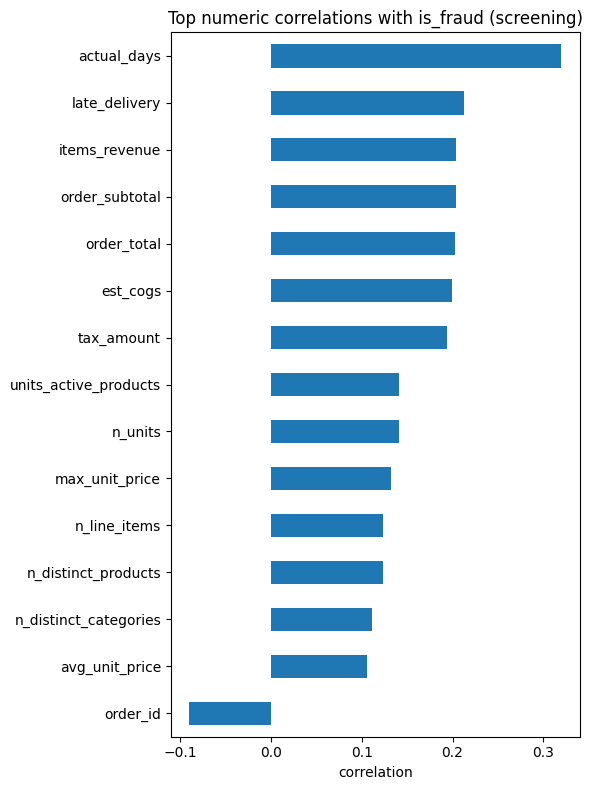

In [10]:
# EDA: fraud rate, plus top numeric correlations (quick screen)

eda_df = df_model[[TARGET_COL] + [c for c in df_model.columns if c != TARGET_COL]].copy()

# 1) Target distribution (again, after cleaning)
counts = eda_df[TARGET_COL].value_counts().sort_index()
fraud_rate = counts.get(1, 0) / counts.sum()
print("n_orders:", int(counts.sum()))
print("fraud_rate:", round(float(fraud_rate), 4))
print(counts.to_string())

# 2) Numeric correlations (only numeric columns)
num_cols_eda = eda_df.select_dtypes(include=["number"]).columns.tolist()
if TARGET_COL in num_cols_eda:
    corr = eda_df[num_cols_eda].corr(numeric_only=True)
    target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=lambda s: s.abs(), ascending=False)
    display(target_corr.head(15).to_frame("corr_with_is_fraud"))

    plt.figure(figsize=(6, 8))
    target_corr.head(15).sort_values().plot(kind="barh")
    plt.title("Top numeric correlations with is_fraud (screening)")
    plt.xlabel("correlation")
    plt.tight_layout()
    plt.show()



Fraud rate by: shipping_state


,count,fraud_rate
shipping_state,,
CO,1702,0.091657
TX,350,0.082857
OR,106,0.075472
VA,47,0.063830
WA,164,0.060976
CA,100,0.060000
FL,244,0.057377
GA,112,0.053571
OH,390,0.048718


<Figure size 700x400 with 0 Axes>

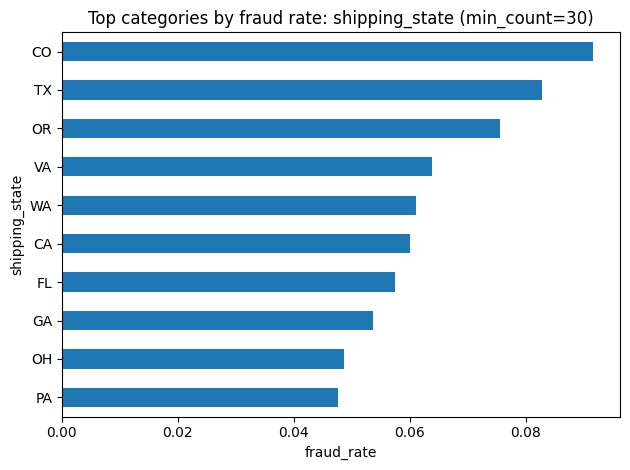


Fraud rate by: payment_method


,count,fraud_rate
payment_method,,
crypto,97,0.103093
card,3128,0.067455
bank,725,0.059310
paypal,1050,0.051429


<Figure size 700x400 with 0 Axes>

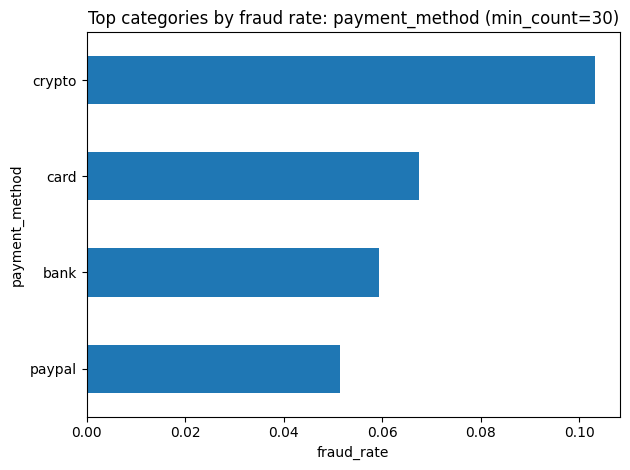


Fraud rate by: device_type


,count,fraud_rate
device_type,,
mobile,2734,0.068032
tablet,364,0.065934
desktop,1902,0.056782


<Figure size 700x400 with 0 Axes>

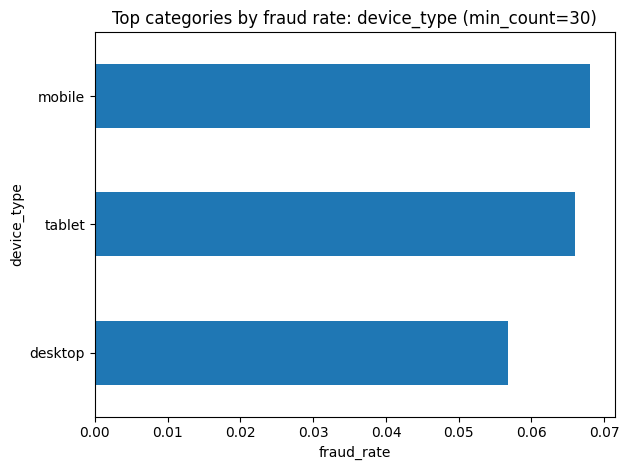


Fraud rate by: ip_country


,count,fraud_rate
ip_country,,
IN,95,0.094737
GB,104,0.086538
BR,41,0.073171
CA,218,0.068807
NG,46,0.065217
US,4496,0.062055


<Figure size 700x400 with 0 Axes>

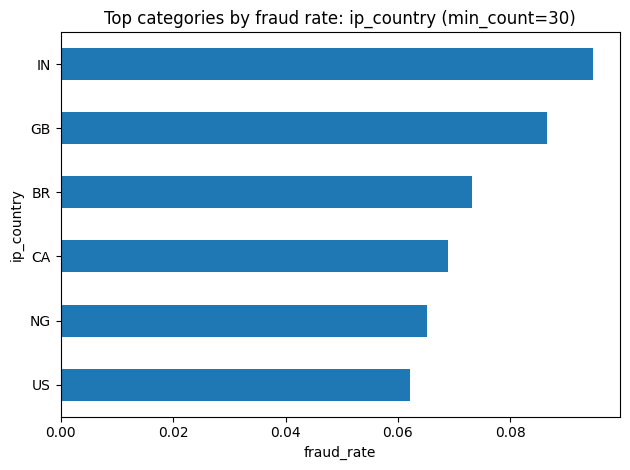


Fraud rate by: customer_segment


,count,fraud_rate
customer_segment,,
standard,2890,0.067128
budget,1764,0.062358
premium,346,0.040462


<Figure size 700x400 with 0 Axes>

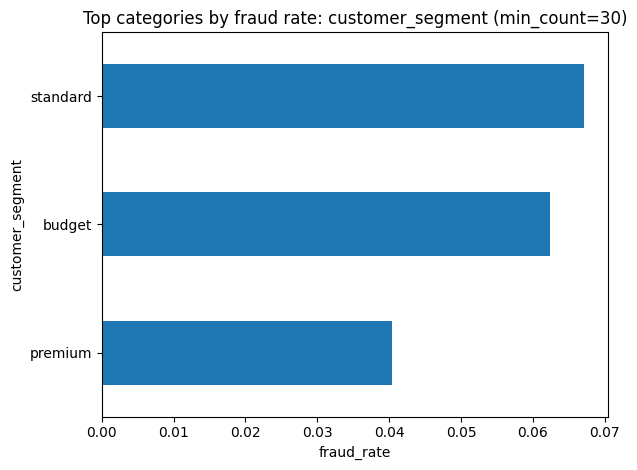


Fraud rate by: loyalty_tier


,count,fraud_rate
loyalty_tier,,
silver,2220,0.073423
none,1930,0.062176
gold,850,0.041176


<Figure size 700x400 with 0 Axes>

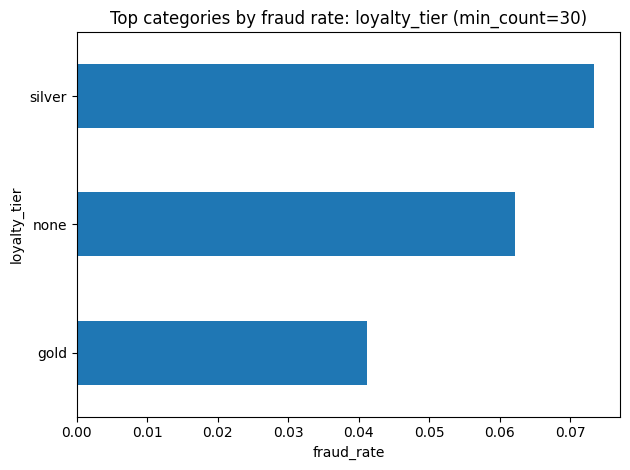


Fraud rate by: carrier


,count,fraud_rate
carrier,,
USPS,997,0.067202
FedEx,1705,0.063930
UPS,2298,0.061793


<Figure size 700x400 with 0 Axes>

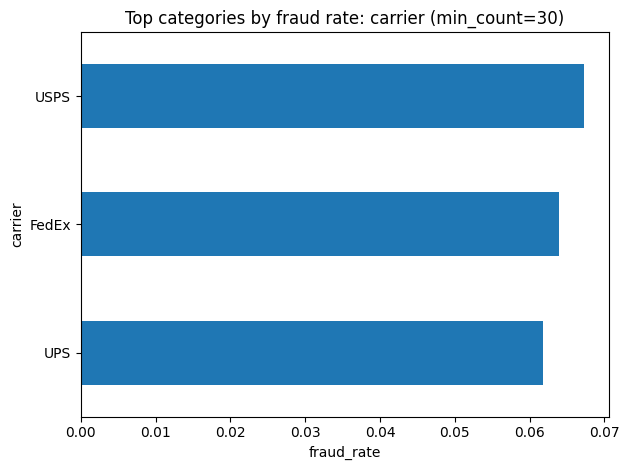


Fraud rate by: shipping_method


,count,fraud_rate
shipping_method,,
overnight,303,0.079208
standard,3618,0.063847
expedited,1079,0.058387


<Figure size 700x400 with 0 Axes>

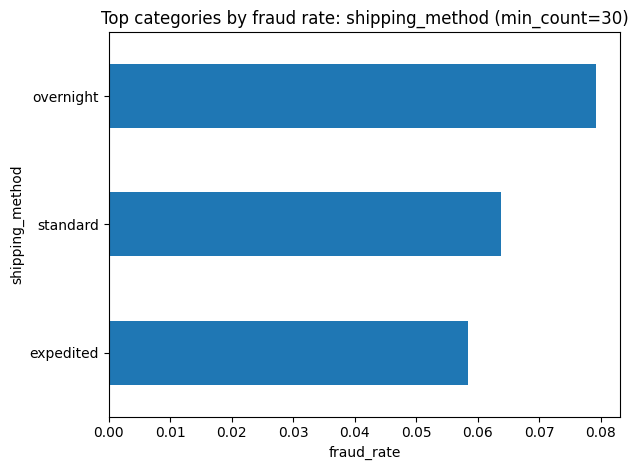


Fraud rate by: distance_band


,count,fraud_rate
distance_band,,
national,990,0.072727
local,1716,0.068765
regional,2294,0.055798


<Figure size 700x400 with 0 Axes>

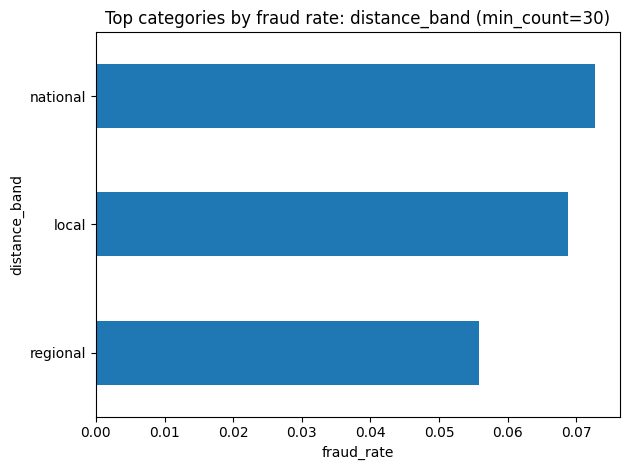

In [11]:
# EDA: fraud rate by category (top categories only to keep it readable)

def fraud_rate_by_category(df: pd.DataFrame, col: str, min_count: int = 30) -> pd.DataFrame:
    """Compute fraud rate by category, filtering to categories with enough rows."""
    tmp = df[[col, TARGET_COL]].copy()
    tmp[col] = tmp[col].astype("object").fillna("(missing)")

    grp = tmp.groupby(col)[TARGET_COL].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})
    grp = grp.sort_values(by="count", ascending=False)
    grp = grp[grp["count"] >= min_count].sort_values(by="fraud_rate", ascending=False)
    return grp

cat_candidates = [
    c for c in df_model.columns
    if c in ["payment_method", "device_type", "ip_country", "shipping_state", "carrier", "shipping_method", "distance_band", "customer_segment", "loyalty_tier"]
    and c in df_model.columns
]

for c in cat_candidates:
    print("\n" + "=" * 80)
    print("Fraud rate by:", c)
    tbl = fraud_rate_by_category(df_model, c, min_count=30)
    display(tbl.head(15))

    if tbl.shape[0] > 0:
        plt.figure(figsize=(7, 4))
        tbl.head(10).sort_values("fraud_rate").plot(y="fraud_rate", kind="barh", legend=False)
        plt.title(f"Top categories by fraud rate: {c} (min_count=30)")
        plt.xlabel("fraud_rate")
        plt.tight_layout()
        plt.show()


## 5) Modeling (Baselines + Ensembles)

Textbook discipline (Ch. 15):
- Freeze a **single** stratified test set once.
- Use cross-validation on the training set for fair comparison.

We will compare the **10 total models** from the Chapter 14 workflow:
- Baselines: Logistic Regression, Shallow Decision Tree, k-NN, Naive Bayes
- Ensembles: Bagging, Random Forest, AdaBoost, Gradient Boosting (GBDT), XGBoost (if available), Stacking

Primary metric focus for fraud:
- **F1** (positive class) and **Average Precision** (PR AUC)


In [12]:
# Freeze a stratified test split once (Chapter 15 discipline)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud rate:", round(float(y_train.mean()), 4))
print("Test fraud rate:", round(float(y_test.mean()), 4))

# Shared CV object for all comparisons
cv = StratifiedKFold(n_splits=5, shuffle=True)


Train shape: (4000, 36)
Test shape: (1000, 36)
Train fraud rate: 0.0635
Test fraud rate: 0.064


In [13]:
# Build the 10-model comparison set (Chapter 14 structure)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# If you run this cell without running the top-of-notebook imports,
# we still want these symbols available.
import numpy as np

# XGBoost is required for this workflow (textbook Chapter 14).
# On macOS, XGBoost may also require the OpenMP runtime (libomp).
# If we hit the common libomp error, we'll print the fix instead of silently skipping.
import sys
import subprocess

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as e:
    print("XGBoost import failed; attempting to install into this notebook kernel...")
    print("Original error:", repr(e))

    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])

    try:
        from xgboost import XGBClassifier
        HAS_XGBOOST = True
    except Exception as e2:
        msg = repr(e2)
        print("\nXGBoost installed but still cannot be imported.")
        print("Error:", msg)

        # Most common macOS issue: missing libomp
        if "libomp" in msg or "libomp.dylib" in msg:
            print("\nFix (macOS): install OpenMP runtime, then restart your notebook kernel:")
            print("  brew install libomp")
            print("After installing, restart the kernel and rerun the notebook.")

        # Hard fail (we do not skip XGBoost)
        raise

# Scoring: focus on positive-class F1 and PR AUC (Average Precision)
scoring = {
    "f1_pos": make_scorer(f1_score, pos_label=1),
    "avg_precision": "average_precision",
    "roc_auc": "roc_auc",
}

# Helper to densify for GaussianNB (because OneHot can produce sparse matrices)
to_dense = FunctionTransformer(
    lambda X: X.toarray() if hasattr(X, "toarray") else np.asarray(X),
    accept_sparse=True,
)

# If you run this as the first cell after a kernel restart, `preprocessor` won't exist yet.
# Recreate the same ColumnTransformer used elsewhere if we have `X_train` from the prep section.

if globals().get("preprocessor", None) is None:
    if globals().get("X_train", None) is None:
        raise RuntimeError(
            "preprocessor is not defined and X_train is missing. "
            "Run the notebook from the top through the train/test split and preprocessing cell, "
            "then run this cell again."
        )

    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    _cat = X_train.select_dtypes(include=["object"]).columns.tolist()
    _num = X_train.select_dtypes(include=["number"]).columns.tolist()

    _numeric_pipe = Pipeline(
        steps=[
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]
    )
    _categorical_pipe = Pipeline(
        steps=[
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", _numeric_pipe, _num),
            ("cat", _categorical_pipe, _cat),
        ],
        remainder="drop",
    )
    print("Note: rebuilt `preprocessor` in this cell (kernel restart or out-of-order run).")

models = []

# --- Baselines (Ch. 14 baseline section) ---
models.append((
    "LogisticRegression",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=2000)),
    ]),
))

models.append((
    "DecisionTree_depth3",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", DecisionTreeClassifier(max_depth=3)),
    ]),
))

models.append((
    "KNN_k15",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", KNeighborsClassifier(n_neighbors=15)),
    ]),
))

models.append((
    "GaussianNB",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("dense", to_dense),
        ("clf", GaussianNB()),
    ]),
))

# --- Ensembles (Ch. 14) ---
base_tree_depth3 = DecisionTreeClassifier(max_depth=3)

models.append((
    "Bagging_depth3",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", BaggingClassifier(
            estimator=base_tree_depth3,
            n_estimators=200,
            bootstrap=True,
            n_jobs=-1,
        )),
    ]),
))

models.append((
    "RandomForest",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            n_jobs=-1,
        )),
    ]),
))

# AdaBoost with decision stumps (depth=1) follows the chapter’s common pattern
models.append((
    "AdaBoost_stumps",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=300,
            learning_rate=0.5,
        )),
    ]),
))

models.append((
    "GradientBoosting_GBDT",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
        )),
    ]),
))

if HAS_XGBOOST:
    models.append((
        "XGBoost",
        Pipeline(steps=[
            ("prep", preprocessor),
            ("clf", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_estimators=500,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                n_jobs=-1,
            )),
        ]),
    ))

# Stacking: combine a few diverse base learners with a logistic regression meta-model
stack_estimators = [
    ("lr", LogisticRegression(max_iter=2000)),
    ("rf", RandomForestClassifier(n_estimators=300, n_jobs=-1)),
    ("knn", KNeighborsClassifier(n_neighbors=15)),
]

models.append((
    "Stacking_LR_RF_KNN",
    Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", StackingClassifier(
            estimators=stack_estimators,
            final_estimator=LogisticRegression(max_iter=2000),
            stack_method="predict_proba",
            cv=5,
            n_jobs=-1,
        )),
    ]),
))

print("Model count:", len(models))
for name, _ in models:
    print("-", name)


Model count: 10
- LogisticRegression
- DecisionTree_depth3
- KNN_k15
- GaussianNB
- Bagging_depth3
- RandomForest
- AdaBoost_stumps
- GradientBoosting_GBDT
- XGBoost
- Stacking_LR_RF_KNN


In [14]:
# Cross-validated comparison table (fair comparison across models)

rows = []
for name, estimator in models:
    t0 = time.time()

    cv_res = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    elapsed = time.time() - t0

    rows.append({
        "model": name,
        "f1_pos_mean": np.mean(cv_res["test_f1_pos"]),
        "f1_pos_std": np.std(cv_res["test_f1_pos"]),
        "avg_precision_mean": np.mean(cv_res["test_avg_precision"]),
        "avg_precision_std": np.std(cv_res["test_avg_precision"]),
        "roc_auc_mean": np.mean(cv_res["test_roc_auc"]),
        "roc_auc_std": np.std(cv_res["test_roc_auc"]),
        "cv_time_sec": elapsed,
    })

results_cv = pd.DataFrame(rows)
results_cv = results_cv.sort_values(by=["avg_precision_mean", "f1_pos_mean"], ascending=False).reset_index(drop=True)
display(results_cv)


,model,f1_pos_mean,f1_pos_std,avg_precision_mean,avg_precision_std,roc_auc_mean,roc_auc_std,cv_time_sec
0,Stacking_LR_RF_KNN,0.623660,0.073511,0.743538,0.060814,0.964907,0.008439,24.233545
1,LogisticRegression,0.631671,0.050925,0.733728,0.020613,0.964293,0.007347,8.161304
2,XGBoost,0.591576,0.025918,0.713330,0.036755,0.962784,0.006443,1.252501
3,GradientBoosting_GBDT,0.550171,0.071236,0.708295,0.062551,0.954098,0.011342,7.942818
4,AdaBoost_stumps,0.501454,0.084445,0.701927,0.037926,0.957464,0.004884,6.207743
5,Bagging_depth3,0.369664,0.053244,0.543380,0.043547,0.896787,0.019126,8.580454
6,DecisionTree_depth3,0.389747,0.065104,0.414363,0.069141,0.864501,0.008858,4.740851
7,RandomForest,0.030334,0.028279,0.388422,0.059733,0.874328,0.023626,5.951835
8,KNN_k15,0.023077,0.030769,0.253976,0.044036,0.802588,0.029074,0.914915
9,GaussianNB,0.145027,0.030345,0.077405,0.015610,0.577435,0.068881,1.026302


## 6) Hyperparameter Tuning (Chapter 15)

We will tune the top-performing models using cross-validation on the training set only.

Guiding principle from the textbook:
- **Keep the test set untouched** until the end.
- Use a consistent CV object + primary metric for tuning.

Primary tuning metric for fraud here: **Average Precision** (PR AUC).


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

# Select top candidates from the CV comparison table
TOP_N = 3
candidates = results_cv.head(TOP_N)["model"].tolist()
print("Top candidates for tuning:")
print(candidates)

# Create a quick name -> estimator lookup
model_dict = {name: est for name, est in models}


Top candidates for tuning:
['Stacking_LR_RF_KNN', 'LogisticRegression', 'XGBoost']


In [16]:
# Define tuning search spaces for a few key model families
# We keep the search sizes modest to keep runtime reasonable in a notebook.

param_spaces = {}

# Logistic Regression
param_spaces["LogisticRegression"] = {
    "clf__C": loguniform(1e-3, 1e2),
    "clf__class_weight": [None, "balanced"],
}

# Random Forest
param_spaces["RandomForest"] = {
    "clf__n_estimators": randint(200, 900),
    "clf__max_depth": [None, 3, 5, 8, 12],
    "clf__min_samples_leaf": randint(1, 30),
    "clf__max_features": ["sqrt", "log2", None],
    "clf__class_weight": [None, "balanced"],
}

# Gradient Boosting (GBDT)
param_spaces["GradientBoosting_GBDT"] = {
    "clf__n_estimators": randint(100, 700),
    "clf__learning_rate": loguniform(1e-2, 2e-1),
    "clf__max_depth": randint(2, 6),
}

# AdaBoost
param_spaces["AdaBoost_stumps"] = {
    "clf__n_estimators": randint(50, 600),
    "clf__learning_rate": loguniform(1e-2, 1.0),
}

# XGBoost (only if available)
if HAS_XGBOOST:
    param_spaces["XGBoost"] = {
        "clf__n_estimators": randint(200, 900),
        "clf__learning_rate": loguniform(1e-2, 2e-1),
        "clf__max_depth": randint(2, 6),
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0],
        "clf__reg_lambda": loguniform(1e-2, 10.0),
    }

# Run RandomizedSearchCV for each candidate that has a defined space
primary_metric = "average_precision"

search_results = []
search_objects = {}

for name in candidates:
    if name not in param_spaces:
        print(f"Skipping tuning for {name}: no param space defined.")
        continue

    estimator = model_dict[name]
    space = param_spaces[name]

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=space,
        n_iter=25,
        scoring=primary_metric,
        cv=cv,
        n_jobs=-1,
        verbose=0,
        return_train_score=False,
    )

    t0 = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - t0

    search_objects[name] = search

    search_results.append({
        "model": name,
        "best_score_avg_precision": float(search.best_score_),
        "best_params": search.best_params_,
        "search_time_sec": elapsed,
    })

results_tuned = pd.DataFrame(search_results).sort_values(by="best_score_avg_precision", ascending=False)
display(results_tuned)


Skipping tuning for Stacking_LR_RF_KNN: no param space defined.


,model,best_score_avg_precision,best_params,search_time_sec
0,LogisticRegression,0.742040,"{'clf__C': 0.14217724496900333, 'clf__class_we...",5.372739
1,XGBoost,0.730547,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",33.247750


## 7) Feature Selection (Chapter 16)

We’ll demonstrate two textbook-aligned approaches:
- **RFECV** (wrapper method) using a tree-based model
- **Permutation Feature Importance** (model-agnostic) on held-out data

Goal: prune to the most predictive variables while keeping evaluation leakage-safe.


In [17]:
# Pick which fitted Pipeline to use for permutation importance + final test evaluation.
# If you restarted the kernel, re-run: (1) model comparison → results_cv, model_dict,
# (2) optional tuning → search_objects, results_tuned.

from sklearn.inspection import permutation_importance  # noqa: F401 — used in the next cell

# Defensive defaults so this cell doesn't crash after a partial run / kernel restart.
search_objects = globals().get("search_objects", {})
results_tuned = globals().get("results_tuned", None)
results_cv = globals().get("results_cv", None)
model_dict = globals().get("model_dict", None)

if results_cv is None or model_dict is None:
    raise RuntimeError(
        "results_cv or model_dict is missing. Re-run the cells that cross-validate the 10 models."
    )

# Use tuning only if we actually have search results keyed by model name.
use_tuned = bool(search_objects) and results_tuned is not None and len(results_tuned) > 0

if use_tuned:
    best_tuned_name = str(results_tuned.iloc[0]["model"])
    if best_tuned_name not in search_objects:
        print("Warning: best tuned name not in search_objects; falling back to CV leader.")
        use_tuned = False

if use_tuned:
    best_model = search_objects[best_tuned_name].best_estimator_
    print("Using best tuned model:", best_tuned_name)
else:
    best_tuned_name = str(results_cv.iloc[0]["model"])
    best_model = model_dict[best_tuned_name]
    print("Using best cross-validated model (no tuning or tuning skipped):", best_tuned_name)

best_model


Using best tuned model: LogisticRegression


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [18]:
# RFECV + Pipeline(ColumnTransformer) often breaks: RFECV masks columns and can pass a NumPy
# array into the pipeline, so column names are lost and OneHotEncoder/ColumnTransformer fails.
# Chapter 16 pattern: preprocess first on TRAINING data only, then RFECV on the numeric matrix
# using an estimator with feature_importances_ (GradientBoostingClassifier).
#
# Runtime: RFECV can take many minutes with large p and many trees/CV folds. Use RFE_THOROUGH
# below to trade speed vs exhaustiveness.

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.base import clone
import numpy as np

# Learn imputation/encoding only from training rows (same leakage logic as a full Pipeline).
prep_rfe = clone(preprocessor)
X_train_proc = prep_rfe.fit_transform(X_train)

# GBDT in scikit-learn expects dense input; densify if the preprocessor output is sparse.
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()

feature_names_rfe = np.array(prep_rfe.get_feature_names_out())

# RFECV is slow by design: for each feature count it refits the model across all CV folds.
# These settings favor **notebook-friendly runtime** over the last bit of accuracy.
# For a more thorough (slower) pass, set RFE_THOROUGH = True below.
RFE_THOROUGH = False

if RFE_THOROUGH:
    n_trees, depth, cv_splits, step, subsample = 200, 3, 3, 1, 1.0
else:
    # Fewer trees, 2 CV folds, and step>1 dramatically cut the number of model fits.
    n_trees, depth, cv_splits, step, subsample = 60, 3, 2, 8, 0.6

gbc_for_rfe = GradientBoostingClassifier(
    n_estimators=n_trees,
    max_depth=depth,
    subsample=subsample,
)

cv_fast = StratifiedKFold(n_splits=cv_splits, shuffle=True)

rfecv = RFECV(
    estimator=gbc_for_rfe,
    step=step,
    cv=cv_fast,
    scoring="average_precision",
    min_features_to_select=5,
    n_jobs=-1,
)

print(
    f"RFECV settings: trees={n_trees}, depth={depth}, cv_splits={cv_splits}, "
    f"step={step}, subsample={subsample}, thorough={RFE_THOROUGH}"
)

rfecv.fit(X_train_proc, y_train)

rfe_selected = feature_names_rfe[rfecv.support_]
print("RFECV selected n_features:", rfecv.n_features_)
print("RFECV best CV score (avg_precision):", float(np.max(rfecv.cv_results_["mean_test_score"])))
print("\nSelected transformed features (first 30):")
for name in rfe_selected[:30]:
    print(" ", name)
if len(rfe_selected) > 30:
    print(" ", f"... and {len(rfe_selected) - 30} more")


RFECV settings: trees=60, depth=3, cv_splits=2, step=8, subsample=0.6, thorough=False
RFECV selected n_features: 5
RFECV best CV score (avg_precision): 0.6708761376517884

Selected transformed features (first 30):
  num__customer_id
  num__tax_amount
  num__promised_days
  num__actual_days
  num__avg_unit_price


,feature,pfi_mean,pfi_std
24,actual_days,0.714304,0.012573
23,promised_days,0.407027,0.031044
21,shipping_method,0.057642,0.012446
20,carrier,0.030863,0.011414
27,n_units,0.022497,0.008110
34,units_active_products,0.022497,0.008110
12,gender,0.018559,0.006625
25,late_delivery,0.015796,0.010675
22,distance_band,0.013574,0.008016
16,customer_state,0.008940,0.006356


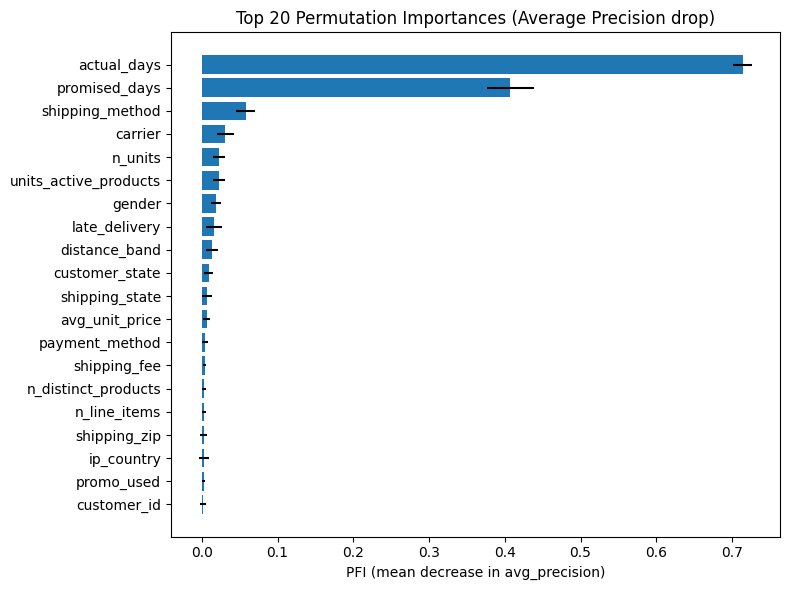

In [19]:
# Permutation importance on the frozen test set (model-agnostic feature importance)
# We'll compute it on the best_model to understand what drives fraud predictions.

import numpy as np
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

best_model.fit(X_train, y_train)

# For permutation importance, we need a scoring function; average_precision aligns with PR focus.
pfi = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=8,
    n_jobs=-1,
)

# Permutation importance shuffles **raw** columns fed into the Pipeline (before prep).
# So there is one score per column of X_test — not per one-hot-expanded name from prep.
if hasattr(X_test, "columns"):
    feature_names = np.asarray(X_test.columns, dtype=object)
else:
    feature_names = np.array([f"feature_{i}" for i in range(X_test.shape[1])], dtype=object)

if len(feature_names) != len(pfi.importances_mean):
    raise ValueError(
        f"PFI length ({len(pfi.importances_mean)}) != feature name count ({len(feature_names)}). "
        "Ensure X_test has the same columns/order as training features."
    )

pfi_df = pd.DataFrame({
    "feature": feature_names,
    "pfi_mean": pfi.importances_mean,
    "pfi_std": pfi.importances_std,
}).sort_values(by="pfi_mean", ascending=False)

display(pfi_df.head(20))

plt.figure(figsize=(8, 6))
top = pfi_df.head(20).sort_values("pfi_mean")
plt.barh(top["feature"], top["pfi_mean"], xerr=top["pfi_std"])
plt.title("Top 20 Permutation Importances (Average Precision drop)")
plt.xlabel("PFI (mean decrease in avg_precision)")
plt.tight_layout()
plt.show()


## 8) Final Evaluation & Selection (Stop here — no deployment)

We will evaluate the selected model on the frozen test set exactly once.

Because fraud is imbalanced, we will emphasize:
- Confusion matrix
- Precision / recall / F1 for the fraud class (1)
- Precision–Recall AUC


<Figure size 500x400 with 0 Axes>

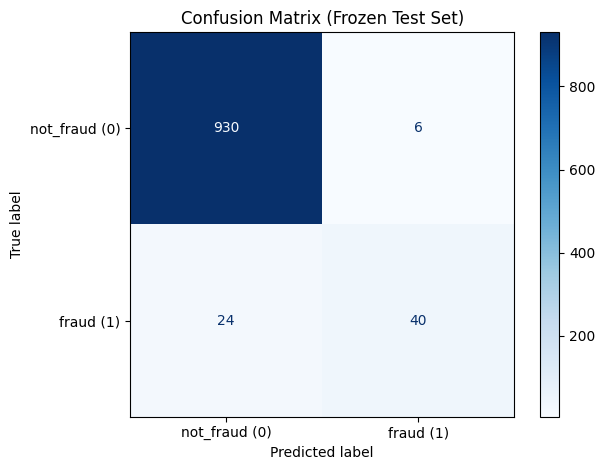

              precision    recall  f1-score   support

           0     0.9748    0.9936    0.9841       936
           1     0.8696    0.6250    0.7273        64

    accuracy                         0.9700      1000
   macro avg     0.9222    0.8093    0.8557      1000
weighted avg     0.9681    0.9700    0.9677      1000

F1 (fraud=1): 0.7273
Average Precision (PR AUC): 0.8052


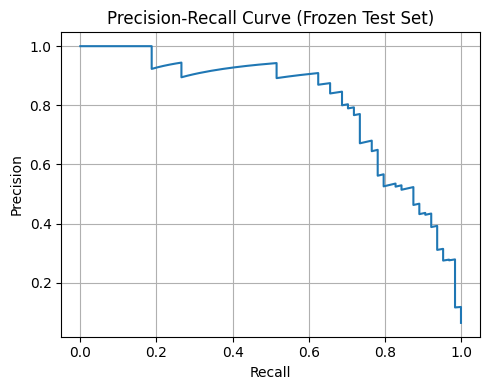

In [20]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    average_precision_score,
    precision_recall_curve,
)

# Final model choice: best_model (already defined above)
final_model = best_model
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

y_proba = None
if hasattr(final_model, "predict_proba"):
    y_proba = final_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["not_fraud (0)", "fraud (1)"]).plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix (Frozen Test Set)")
plt.tight_layout()
plt.show()

# Classification report emphasizes per-class precision/recall/F1
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

# Key fraud-focused summary metrics
f1_pos = f1_score(y_test, y_pred, pos_label=1)
print("F1 (fraud=1):", round(float(f1_pos), 4))

if y_proba is not None:
    ap = average_precision_score(y_test, y_proba)
    print("Average Precision (PR AUC):", round(float(ap), 4))

    # Precision-Recall curve
    prec, rec, thr = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(rec, prec)
    plt.title("Precision-Recall Curve (Frozen Test Set)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Model selection rationale (fraud context)

In fraud detection, overall accuracy is often misleading because the non-fraud class dominates.

We therefore prioritize:
- **Recall** for fraud (how many fraudulent orders we catch)
- **Precision** for fraud (how many flagged orders are truly fraud)
- **F1** (single-number summary of the precision/recall tradeoff)
- **PR AUC / Average Precision** (ranking quality under class imbalance)

This notebook intentionally stops here (no serialization/deployment), per the assignment constraint.


### Serialize fitted model (optional artifact)

The cell below saves the **entire fitted `Pipeline`** (preprocessing + classifier) so you can load it later and call `predict` / `predict_proba` on new rows that use the **same feature columns** as `X_train` (after the same SQL/feature construction used in this notebook).

This does not replace the database; it only stores the trained algorithm for batch or API scoring.


In [21]:
import joblib

# Save the fitted end-to-end pipeline so predictions use the same imputation, scaling,
# and one-hot encoding as training (avoids training-serving skew).
# `final_model` is the Pipeline from the "Final Evaluation" cell (preprocessor + classifier).

MODEL_SAV_PATH = os.path.join(PROJECT_ROOT, "fraud_model_pipeline.sav")
joblib.dump(final_model, MODEL_SAV_PATH)
print("Saved fitted pipeline to:", MODEL_SAV_PATH)
print(f"Load later with: model = joblib.load({MODEL_SAV_PATH!r})")


Saved fitted pipeline to: /Users/brytongustin/Downloads/Winter_Junior_Core/455/ML_Deployment/fraud_model_pipeline.sav
Load later with: model = joblib.load('/Users/brytongustin/Downloads/Winter_Junior_Core/455/ML_Deployment/fraud_model_pipeline.sav')


In [22]:
# Clean up the database connection
conn.close()
print("Done.")


Done.
